In [1]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
dataset_train = '/kaggle/input/waste-classification-data/DATASET/TRAIN'
dataset_test = '/kaggle/input/waste-classification-data/DATASET/TEST'

In [3]:
img_path_train = []
labels_train = []

for category in ['O', 'R']:
    category_path = os.path.join(dataset_train, category)
    files = os.listdir(category_path)
    for file_name in files:
        file_path = os.path.join(category_path, file_name)
        img_path_train.append(file_path)
        labels_train.append(0 if category == 'O' else 1)

In [4]:
img_path_test = []
labels_test = []

for category in ['O', 'R']:
    category_path = os.path.join(dataset_test, category)
    files = os.listdir(category_path)
    for file_name in files:
        file_path = os.path.join(category_path, file_name)
        img_path_test.append(file_path)
        labels_test.append(0 if category == 'O' else 1)

In [6]:
images_valid_train = []
labels_valid_train = []

for path, label in zip(img_path_train, labels_train):
    im = cv2.imread(path)
    if im is None:
        print(f"Imagem corrompida: {path}")
    else:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        im = cv2.resize(im, (64,64))
        images_valid_train.append(im)
        labels_valid_train.append(label)

X_train = np.array(images_valid_train)
y_train = np.array(labels_valid_train)

In [7]:
images_valid_test = []
labels_valid_test = []

for path, label in zip(img_path_test, labels_test):
    im = cv2.imread(path)
    if im is None:
        print(f"Imagem corrompida: {path}")
    else:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        im = cv2.resize(im, (64,64))
        images_valid_test.append(im)
        labels_valid_test.append(label)

X_test = np.array(images_valid_test)
y_test = np.array(labels_valid_test)

In [8]:
X_train.shape

(22564, 64, 64, 3)

In [9]:
y_train.shape

(22564,)

In [10]:
y_test.shape

(2513,)

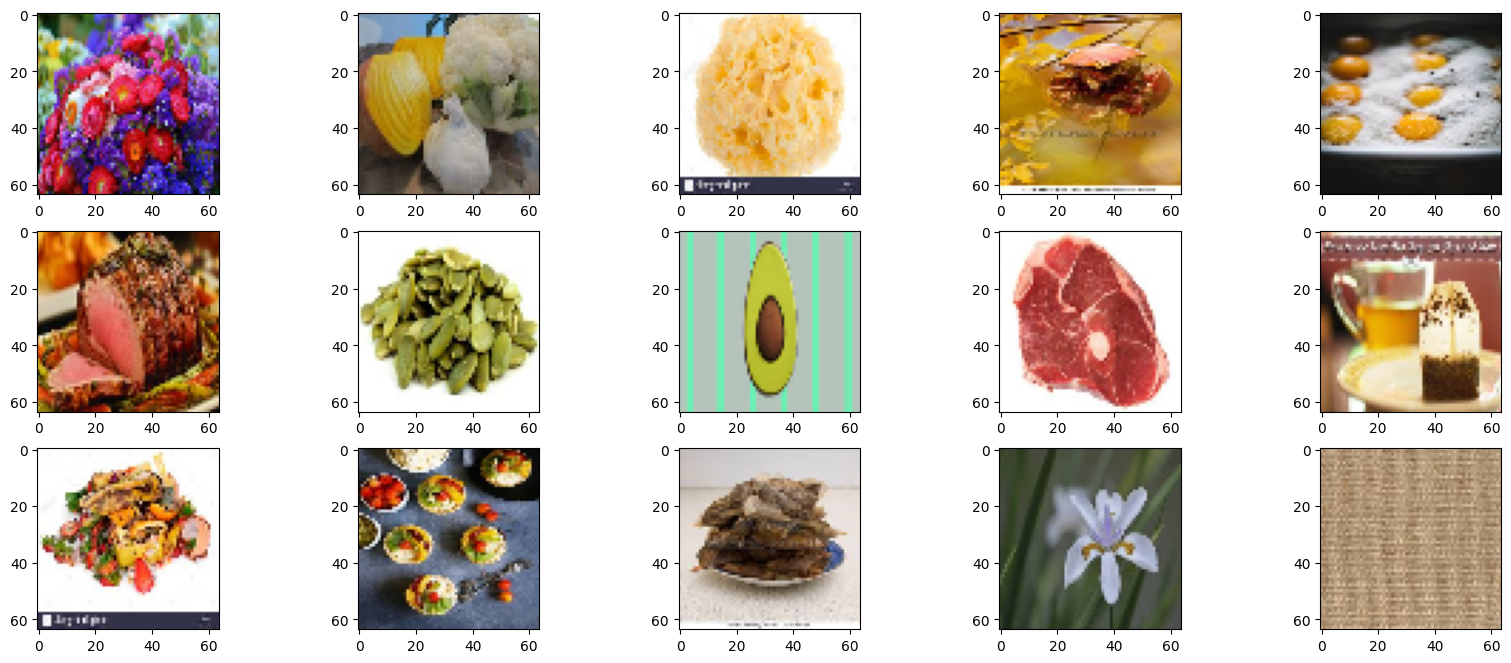

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,5, figsize=(20,8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization



model = Sequential()
model.add(Input(shape=(64,64,3)))

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))


model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))  # Dropout para evitar overfitting
model.add(Dense(1, activation='sigmoid'))

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,288,577 (16.36 MB)

 Trainable params: 4,288,577 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(patience=3)

history = model.fit(datagen.flow(X_train, y_train, batch_size=16),
                    epochs=50,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1411/1411 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.7260 - loss: 0.5435 - val_accuracy: 0.8683 - val_loss: 0.4365
Epoch 2/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7972 - loss: 0.4551 - val_accuracy: 0.8532 - val_loss: 0.4300
Epoch 3/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8082 - loss: 0.4278 - val_accuracy: 0.8679 - val_loss: 0.3622
Epoch 4/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8204 - loss: 0.4044 - val_accuracy: 0.8631 - val_loss: 0.3557
Epoch 5/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8338 - loss: 0.3827 - val_accuracy: 0.8679 - val_loss: 0.3419
Epoch 6/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8353 - loss: 0.3768 - val_accuracy: 0.8659 - val_loss: 0.3336
Epoch 7/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8461 - loss: 0.3645 - val_accuracy: 0.8830 - val_loss: 0.3112
Epoch 8/50
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8421 - loss: 0.36

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


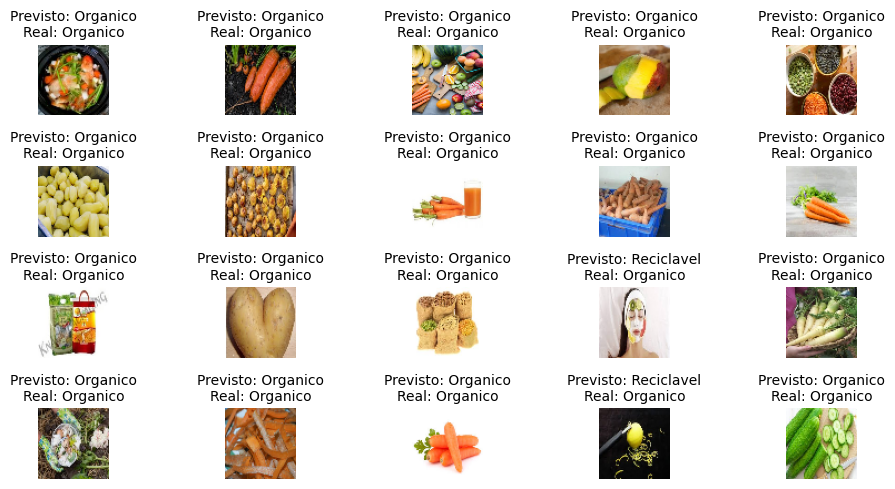

In [26]:
class_names = ['Organico', 'Reciclavel']

# Fazer previsões no conjunto de teste
predictions = model.predict(X_test)

# Obter as labels previstas
if predictions.shape[1] == 1:  # Classificação binária
    predicted_labels = (predictions > 0.5).astype(int).flatten()
else:  # Multiclasse
    predicted_labels = np.argmax(predictions, axis=1)

# Exibir as imagens com os nomes das labels previstas e reais
num_images = 20 
plt.figure(figsize=(10, 5))

for i in range(num_images):
    plt.subplot(4, 5, i + 1)  # Criar subplots (2 linhas, 5 colunas)
    plt.imshow(X_test[i])  # Mostrar a imagem (verifique se X_test está em formato de imagem)
    plt.title(
        f"Previsto: {class_names[predicted_labels[i]]}\nReal: {class_names[y_test[i]]}",
        fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [27]:
model.save("model_amb.h5")